# Part 6 · Execution & Toward Hardware

Everything we have built so far (circuits in Part 2, Hamiltonians and annealing in Part 3, VQE and QAOA in Part 4, noise in Part 5) ran on one simulator, `QiliSim`. This final part is about **execution itself**: what it takes to run the *same* program somewhere else, where "somewhere else" can be a GPU, a different simulation engine, a colleague's toolchain, or a real quantum chip in a dilution fridge.

Each idea in this part has a classical counterpart you already know:

- **Backend swapping** is moving numpy code to CuPy, or pointing the same database API at a different driver: the program stays put, one object changes.
- **OpenQASM / QIR interop** is JSON for circuits: export your circuit as text, hand it to any other toolchain, read theirs back.
- **The transpiler** is a compiler backend: your logical circuit is source code, a real chip has a small instruction set and fixed wiring, and the transpiler lowers one onto the other.
- **SpeQtrum** is a remote job queue for real QPUs (QPU = quantum processing unit, the physical chip): you submit a job, wait in the queue, and fetch results, much like a CI pipeline.

> **On "pulse-level".** QiliSDK 0.2.1 does **not** expose a pulse/waveform API (there are no `Pulse` or `Channel` objects). What it *does* give you is a real descent toward hardware: **native-gate transpilation**, the analog **`Schedule`** as continuous-time control, and remote QPU/pulse experiments via **SpeQtrum**.

By the end of this notebook you will have:

- retargeted Part 4's molecule energy measurement across up to three engines by swapping one object;
- exported the QAOA placement circuit to OpenQASM 3 and back, losslessly;
- compiled that circuit onto a 4-qubit chip topology and counted what routing costs;
- built the capstone: a **quantum-reservoir forecaster** whose only trained component is a numpy linear regression.

In [1]:
# ▶ Run me first. No-op if QiliSDK is already installed; installs it on a fresh env (e.g. Google Colab).
try:
    import qilisdk
except ImportError:
    import sys
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install",
                    "qilisdk[openqasm,qir]==0.2.1", "matplotlib", "numpy"], check=True)
    import qilisdk  # Colab: if this still fails, Runtime > Restart session, then rerun
print("QiliSDK", qilisdk.__version__)

QiliSDK 0.2.1


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## 6.0 · The execution layer

Recall the three-layer architecture from the slides (`overall.jpg`). A **Functional** (*what* to run) plus a **Readout** (*what to measure*) is completely **backend-independent**: nothing in `DigitalPropagation(circuit)` or `Readout().with_expectation(...)` knows where it will execute. The bottom layer, **Backends**, decides *where*:

- **`QiliSim`**: the built-in C++ CPU simulator, always installed, the engine behind every result in Parts 1 to 5;
- **`CudaBackend`**: GPU acceleration via NVIDIA CUDA-Q (optional extra `qilisdk[cuda12]` or `[cuda13]`);
- **`QutipBackend`**: CPU simulation via the QuTiP library (optional extra `qilisdk[qutip]`);
- **`SpeQtrum`**: a *client* for Qilimanjaro's real QPUs (not a `Backend` object; it appears later in this part).

Retargeting a program is literally *constructing a different backend object* and calling the same `.execute(functional, readout)`. That is the whole trick, and it pays off directly: you prototype on your laptop, profile on a GPU, and queue on real hardware **without touching the science code**, the same way well-factored data code moves between SQLite and Postgres by swapping the connection object.

## 6.1 · Swap the backend (on a real molecule)

We demonstrate that claim on the most significant number in the tutorial: the ground-state energy of the H$_2$ molecule from Part 4 (the electronic energy at bond length 0.7414 angstrom, the problem a Google/UCSB team ran on real superconducting hardware in 2016).

In Part 4, VQE *searched* for the lowest-energy state with an optimizer. Here we skip the search: the optimal state VQE found can be prepared directly by a small 3-gate circuit, a single `RY` rotation with angle $\theta = -2.9118$, a `CNOT`, and an `X`. (Part 4's VQE searched over a 12-parameter `U3` ansatz and never reported this angle; $\theta$ here is chosen so that this compact 3-gate circuit reproduces the ground state VQE found.) Knowing the *structure* of the answer lets us shrink the circuit; in effect we are caching the result of Part 4's training loop.

Two practical notes before the code:

- **Name collision, in practice.** This cell uses digital gates (`RY`, `CNOT`, `X`) *and* analog Pauli observables, which share the names `X, Y, Z, I`. As in Parts 3 to 5, we alias the analog ones (`aI, aX, aY, aZ`). Both appear together in the one file below.
- **Optional backends are import-or-stub.** `from qilisdk.backends import CudaBackend` *always* succeeds, but on a machine without the extra installed you get a stub that raises `OptionalDependencyError` (a subclass of `ImportError`) the moment you *use* it. We guard each optional engine with `try/except`, so on a typical laptop the expected output is one energy plus two "not installed" lines. That is the intended outcome: the point is that the *code* did not change.

In [3]:
from qilisdk.analog import I as aI, X as aX, Y as aY, Z as aZ   # analog Paulis: observables
from qilisdk.digital import Circuit, RY, CNOT, X                 # digital gates: the program
from qilisdk.functionals import DigitalPropagation
from qilisdk.readout import Readout
from qilisdk.backends import QiliSim
from qilisdk._optionals import OptionalDependencyError

# The H2 molecule Hamiltonian from Part 4 (O'Malley et al., PRX 6, 031007 (2016))
g0, g1, g2, g3, g4, g5 = -0.4804, 0.3435, -0.4347, 0.5716, 0.0910, 0.0910
H_mol = (g0 * aI(0) + g1 * aZ(0) + g2 * aZ(1) + g3 * aZ(0) * aZ(1)
         + g4 * aY(0) * aY(1) + g5 * aX(0) * aX(1))
exact_energy = np.linalg.eigvalsh(H_mol.to_matrix().toarray()).min()
print(f"exact ground energy: {exact_energy:.6f} Ha")

# The ground state VQE found in Part 4, prepared directly by 3 gates
theta = -2.9118
prep = Circuit(2)
prep.add(RY(0, theta=theta))
prep.add(CNOT(0, 1))
prep.add(X(1))

functional = DigitalPropagation(prep)                                 # WHAT to run
readout = Readout().with_expectation(observables=[H_mol], nshots=0)   # WHAT to measure (nshots=0: exact)

energy = QiliSim().execute(functional, readout).get_expectation_values()[0]
print(f"QiliSim      : {energy:.6f} Ha")

try:
    from qilisdk.backends import QutipBackend
    energy = QutipBackend().execute(functional, readout).get_expectation_values()[0]
    print(f"QutipBackend : {energy:.6f} Ha")
except OptionalDependencyError:
    print("QutipBackend : not installed here (expected on most laptops) -> pip install qilisdk[qutip]")

try:
    from qilisdk.backends import CudaBackend
    energy = CudaBackend().execute(functional, readout).get_expectation_values()[0]
    print(f"CudaBackend  : {energy:.6f} Ha")
except OptionalDependencyError:
    print("CudaBackend  : not installed here (expected on most laptops) -> pip install qilisdk[cuda12]")

exact ground energy: -1.851199 Ha
QiliSim      : -1.851199 Ha
QutipBackend : -1.851199 Ha


CudaBackend  : -1.851199 Ha


Every engine that runs prints **-1.851199 Ha**, matching the exact diagonalization to the last digit: different simulators, one program, no code changes. (This machine may have the optional extras installed; on most laptops the two guarded blocks will print their "not installed" lines, which is what they are for.)

### Configuring `QiliSim`

Simulation *strategy* is data, kept separate from the program. `QiliSim` accepts three config objects: `AnalogMethod` (which time-evolution integrator to use), `DigitalMethod` (state-vector options), and `ExecutionConfig` (threads, seed, Monte Carlo settings). You rarely need any of them at tutorial scale, but one **trap** is worth knowing before you read the vendor docs:

> ⚠️ These configs are pydantic models that **silently ignore unknown keyword arguments**. A tempting mistake is `ExecutionConfig(analog_method=...)`, which does *not* raise an error: it silently drops the setting and you run with the default integrator (wrong physics, no warning). The analog method belongs on the backend instead: `QiliSim(analog_simulation_method=AnalogMethod.direct())`. When a config seems to have no effect, check the keyword name first.

## 6.2 · Interoperability: your circuits are not locked in

Say your colleague works in Qiskit, or your company's compiler team wants to inspect your circuit, or a hardware vendor only accepts a standard format. Quantum computing has its interchange formats, and QiliSDK speaks two:

- **OpenQASM 3**: the human-readable "quantum assembly" used across the ecosystem. Think *JSON for circuits*: a plain-text serialization every major toolchain can parse.
- **QIR** (Quantum Intermediate Representation): an LLVM-based format, *bytecode for quantum programs*, aimed at compiler toolchains rather than humans.

Both live as **module-level functions** (`qilisdk.utils.openqasm`, `qilisdk.utils.qir`), not methods on `Circuit`, and both need optional extras (our install cell already requested `qilisdk[openqasm,qir]`).

The circuit worth exporting is a real one: the **microservice placement** QAOA circuit from Part 4. Quick recap of the problem: four services (`auth`, `api`, `db`, `cache`) must be split across two servers, exactly two per server, minimizing cross-server traffic. The expression `x[a] + x[b] - 2 x[a] x[b]` equals 1 exactly when services $a$ and $b$ sit on *different* servers, so summing it with traffic weights measures the cross-server traffic; the balance constraint becomes a penalty term with weight 1000. `Model` → `to_qubo()` → `to_hamiltonian()` compiles it to a 4-qubit Ising Hamiltonian, and `QAOA(ham, layers=1)` builds the circuit with two parameters (`gamma_0`, `alpha_0`).

One wrinkle: a QASM file describes *concrete* gates, so we first **bind** the two angles to fixed values with `set_parameters` (0.3 is arbitrary here; in production you would bind the optimizer's best angles from Part 4).

In [4]:
from qilisdk.core import Model, BinaryVariable, ObjectiveSense
from qilisdk.core.variables import EQ
from qilisdk.digital import QAOA

# The shared placement problem from Part 4
services = ["auth", "api", "db", "cache"]
traffic = {("auth", "api"): 120, ("api", "db"): 300, ("api", "cache"): 200,
           ("db", "cache"): 250, ("auth", "db"): 20}

x = {s: BinaryVariable(f"x_{s}") for s in services}       # 0 = server A, 1 = server B
cross = sum(w * (x[a] + x[b] - 2 * x[a] * x[b]) for (a, b), w in traffic.items())
model = Model("placement")
model.set_objective(cross, sense=ObjectiveSense.MINIMIZE)
model.add_constraint("balance", EQ(sum(x[s] for s in services), 2), lagrange_multiplier=1000)
ham = model.to_qubo().to_hamiltonian()

qaoa = QAOA(ham, layers=1)
print("parameters:", qaoa.get_parameter_names())
qaoa.set_parameters({name: 0.3 for name in qaoa.get_parameter_names()})   # bind the angles
print("logical circuit:", len(qaoa.gates), "gates on", qaoa.nqubits, "qubits")

parameters: ['gamma_0', 'alpha_0']
logical circuit: 34 gates on 4 qubits


Now export it. In the OpenQASM text below, look for two things: the `h q[...]` lines (the uniform-superposition start every QAOA has) and the `ctrl @ x q[i], q[j];` lines, which are the CNOTs of the problem layer (a controlled `x` is exactly how OpenQASM 3 spells CNOT). The `rz(...)` lines between them carry the bound angles. The round-trip check at the end is the point of the demo: **export, re-import, and prove that not a single gate changed**.

In [5]:
try:
    from qilisdk.utils.openqasm import to_qasm3, from_qasm3

    qasm = to_qasm3(qaoa)
    qasm_lines = qasm.splitlines()
    print("=== OpenQASM 3, first 12 of", len(qasm_lines), "lines ===")
    print("\n".join(qasm_lines[:12]))

    qasm_recovered = from_qasm3(qasm)                          # parse the text back into a Circuit
    assert [str(g) for g in qasm_recovered.gates] == [str(g) for g in qaoa.gates]
    print("\nround-trip: PASSED, all", len(qaoa.gates), "gates identical")
except ImportError:
    print("OpenQASM extra not installed -> pip install qilisdk[openqasm]")

try:
    from qilisdk.utils.qir import to_qir

    qir = to_qir(qaoa, name="placement_qaoa")              # `name` is keyword-only
    qir_lines = qir.splitlines()
    print("\n=== QIR, first 12 lines of", len(qir_lines), "lines ===")
    print("\n".join(qir_lines[:12]))
except ImportError:
    print("QIR extra not installed -> pip install qilisdk[qir]")

=== OpenQASM 3, first 12 of 37 lines ===
OPENQASM 3.0;
include "stdgates.inc";
qubit[4] q;
h q[0];
h q[1];
h q[2];
h q[3];
ctrl @ x q[0], q[1];
rz(0.3) q[1];
ctrl @ x q[0], q[1];
ctrl @ x q[0], q[3];
rz(0.3) q[3];

round-trip: PASSED, all 34 gates identical

=== QIR, first 12 lines of 56 lines ===
; ModuleID = 'placement_qaoa'
source_filename = "placement_qaoa"

define void @main() #0 {
entry:
  call void @__quantum__qis__h__body(ptr null)
  call void @__quantum__qis__h__body(ptr inttoptr (i64 1 to ptr))
  call void @__quantum__qis__h__body(ptr inttoptr (i64 2 to ptr))
  call void @__quantum__qis__h__body(ptr inttoptr (i64 3 to ptr))
  call void @__quantum__qis__cnot__body(ptr null, ptr inttoptr (i64 1 to ptr))
  call void @__quantum__qis__rz__body(double 2.640000e+02, ptr inttoptr (i64 1 to ptr))
  call void @__quantum__qis__cnot__body(ptr null, ptr inttoptr (i64 1 to ptr))


## 6.3 · Toward hardware: the compiler

There is a gap between everything we have written and a physical chip. Real QPUs do **not** run arbitrary gates between arbitrary qubits:

- Each chip supports a small **native gate set**, its instruction set. A typical superconducting chip natively performs single-qubit rotations (`RX`/`RY`/`RZ`, implemented as shaped microwave pulses) and *one* two-qubit gate (often `CZ`). There is no physical `H` or `CNOT` button.
- Each chip has a fixed **topology** (also called a coupling map): two-qubit gates only work between qubits that are physically wired together by a coupler.

Bridging that gap is a **compilation** problem, and the analogy is exact. Your `H`/`CNOT` circuit is portable source code. **Decomposition** is lowering it to the target's instruction set, like a compiler turning C into x86 or ARM instructions. **Routing** is register allocation: when a two-qubit gate needs qubits that are not adjacent, the router inserts `SWAP` gates to physically shuttle the quantum state across the chip until the two operands sit on connected qubits, the way a compiler shuffles values between registers and memory. Each inserted SWAP costs **three** native two-qubit gates, so routing is expensive and worth optimizing. QiliSDK's router uses **SABRE**, a heuristic routing algorithm also used by production compilers (it is stochastic: two runs may find different, equally valid routings).

`CircuitTranspiler.default(...)` assembles the whole pass pipeline. (Import it from `qilisdk.digital.circuit_transpiler`; `Circuit` has no `.transpile()` method.) Let's compile the placement QAOA circuit onto a 4-qubit chip whose qubits are wired in a **line**:

```text
0 -- 1 -- 2 -- 3
```

The QAOA circuit contains `CNOT`s between *every* pair of the 4 qubits (the problem Hamiltonian couples all pairs), and pairs like (0, 3) are not connected. The router has real work to do.

In [6]:
from collections import Counter
from qilisdk.digital.circuit_transpiler import (
    CircuitTranspiler, SingleQubitGateBasis, TwoQubitGateBasis,
)

line = [(0, 1), (1, 2), (2, 3)]                           # the chip's couplers

transpiler = CircuitTranspiler.default(
    single_qubit_basis=SingleQubitGateBasis.RxRyRz,       # a superconducting-style native set
    two_qubit_basis=TwoQubitGateBasis.CZ,
    topology=line,
)
line_result = transpiler.transpile(qaoa)

logical_counts = Counter(type(g).__name__ for g in qaoa.gates)
native_counts = Counter(type(g).__name__ for g in line_result.circuit.gates)
print("logical:", dict(logical_counts), "-> total", sum(logical_counts.values()))
print("native :", dict(native_counts), "-> total", sum(native_counts.values()))

# The stable invariant: EVERY two-qubit gate now sits on a physical coupler
line_edges = {frozenset(edge) for edge in line}
line_two_qubit = [g for g in line_result.circuit.gates if len(g.qubits) == 2]
assert all(frozenset(g.qubits) in line_edges for g in line_two_qubit), "a 2-qubit gate missed the couplers!"
print("two-qubit gates:", len(line_two_qubit), "-> all placed on couplers")

print("\npass pipeline:")
for step in line_result.intermediate_results:
    print("  ", step.name)

logical: {'H': 12, 'CNOT': 12, 'RZ': 10} -> total 34
native : {'RZ': 17, 'RY': 23, 'CZ': 21, 'RX': 7} -> total 68
two-qubit gates: 21 -> all placed on couplers

pass pipeline:
   DecomposeMultiControlledGatesPass
   CancelIdentityPairsPass
   DecomposeToCanonicalBasisPass
   FuseSingleQubitGatesPass
   SabreLayoutPass
   SabreSwapPass
   DecomposeToCanonicalBasisPass
   FuseSingleQubitGatesPass


Compare the two gate inventories. The logical circuit had 34 gates (`H`, `CNOT`, `RZ`); the native one is written entirely in `RX`/`RY`/`RZ`/`CZ` and has **roughly twice as many** (the exact total varies run to run because SABRE is stochastic; rerun the cell to see it change). The `assert` checks the one thing that never varies: every two-qubit gate lands on a physical coupler.

The pass pipeline you printed is a real compiler pipeline: decomposition passes lower to the basis, fusion passes cancel and merge single-qubit gates (an optimizer!), and the two SABRE passes choose the initial qubit **layout** and insert the routing SWAPs.

Now connect this to Part 5, because this is where hardware quality becomes an engineering budget. Noise compounds **per gate**: if each two-qubit gate succeeds with probability $1-p$, a circuit with $G$ of them succeeds with roughly $(1-p)^G$. Compilation roughly *doubled* our gate count without changing the algorithm at all, and every SWAP the router inserted is three more chances to fail. This is why "how many qubits?" is the wrong first question about a quantum chip; **how they are wired, and how good the gates are** decides what you can actually run.

### 🧩 Exercise 6.1 · Evaluate a chip upgrade

Your team can afford **one hardware upgrade** for this 4-qubit line chip: an extra coupler between qubits 3 and 0, closing the line into a **ring**. The vendor claims it is worth the cost. Use the compiler to check.

**Goal:** transpile the *same* `qaoa` circuit onto the ring topology and compare the number of native **two-qubit gates** against the line result (`line_two_qubit` is still in memory from the demo).

**Why it matters:** every SWAP the extra coupler saves is three two-qubit gates removed from the $(1-p)^G$ error budget of Part 5, for *every* circuit this chip will ever run.

**Hints**

- Build the transpiler exactly as in the demo; the only thing that changes is `topology=`.
- Keep the all-gates-on-couplers `assert`, adapted to the ring's edge set.
- SABRE is stochastic: counts vary between runs, and the ring usually needs fewer gates. If the two counts tie, rerun the cell a couple of times and compare the trend.

In [7]:
ring = [(0, 1), (1, 2), (2, 3), (3, 0)]   # the line plus ONE extra coupler

# solution: same native basis, one extra coupler in the topology
ring_transpiler = CircuitTranspiler.default(
    single_qubit_basis=SingleQubitGateBasis.RxRyRz,
    two_qubit_basis=TwoQubitGateBasis.CZ,
    topology=ring,
)
ring_result = ring_transpiler.transpile(qaoa)

ring_edges = {frozenset(edge) for edge in ring}
ring_two_qubit = [g for g in ring_result.circuit.gates if len(g.qubits) == 2]
assert all(frozenset(g.qubits) in ring_edges for g in ring_two_qubit), "a 2-qubit gate missed the couplers!"
print("line topology:", len(line_two_qubit), "two-qubit gates")
print("ring topology:", len(ring_two_qubit), "two-qubit gates")
# Answer: the extra coupler. It removes whole SWAPs (three two-qubit gates each)
# from every circuit this chip will ever route, shrinking the exponent G in the
# (1-p)^G survival probability from Part 5. Faster gates only shrink each gate's
# error window p by a constant factor; fewer gates attack the exponent itself.

line topology: 21 two-qubit gates
ring topology: 21 two-qubit gates


### Where true pulse-level control lives

One last section to close out the hardware descent. Below the native gates sits the **pulse** layer: a pulse is a shaped microwave signal sent down a control line, and every native gate is *implemented* as one or a few calibrated pulses. Laboratory work at that layer has its own vocabulary: a **Rabi experiment** measures how strongly a pulse of given amplitude rotates a qubit (it is how labs calibrate `RX`), and **$T_1$** (from Part 5) is measured by pulsing the qubit to $|1\rangle$ and timing the decay.

QiliSDK gives you two things adjacent to that layer:

1. **The analog `Schedule` (Part 3) is continuous-time control.** A schedule specifies $H(t) = \sum_k c_k(t) H_k$: a set of Hamiltonian building blocks $H_k$, each with its own time-dependent coefficient $c_k(t)$ that you shape like an envelope. That is genuinely *continuous* control, but at the Hamiltonian level: there is no carrier frequency, no physical drive channel. Call it pulse-*shaped*, not pulse-level.
2. **Real pulse experiments run remotely via `SpeQtrum`**, Qilimanjaro's client for their QPUs, with a job-queue workflow any developer will recognize. This is a sketch, not a runnable cell: it needs an account and a chip in a lab.

```python
# NON-RUNNABLE SKETCH: the SpeQtrum remote-hardware workflow
SpeQtrum.login(username, apikey)          # authenticate once
client = SpeQtrum()
devices = client.list_devices()           # which chips are online?
job = client.submit(functional, device, readout)   # enqueue, like pushing a CI job
client.wait_for_job(job)                  # the queue runs it when your turn comes
results = job.get_results()
```

The concrete pulse experiments (Rabi, $T_1$ and friends) live in a separate `qili-experiments` plugin on the hardware side; core `qilisdk` ships only their abstract interfaces. So: simulate and compile locally, and when you get QPU access, the *same functional and readout objects* are what you submit.

## 6.4 · Capstone: forecasting a sensor signal with a quantum reservoir

For the finale we combine everything (analog evolution, digital encoding, expectation readout, and plain numpy) into a working machine-learning micro-pipeline: **Quantum Reservoir Computing (QRC)**.

If you have ever done transfer learning, you already know the shape of this idea: **freeze the backbone, train only the last layer**. In QRC the "backbone" is a fixed quantum system called the **reservoir**. We feed data into it, let its natural dynamics scramble that data into a rich high-dimensional state, measure a handful of expectation values as a **feature vector**, and train a **classical linear regression** on those features. Nothing quantum is ever trained: no gradients flow through the quantum system, so there are no barren plateaus (the vanishing-gradient problem that plagues variational circuits) and no parameter updates to calibrate on hardware. That is precisely why QRC is a serious candidate workload for near-term *analog* machines.

**The task.** A sensor on a slowly cycling machine logs 40 noisy readings (a sine wave plus noise). We want to forecast the **next reading** from the history so far, and beat the embarrassingly strong naive baseline "tomorrow equals today".

**The architecture** (this is the loop in the `reservoirs.jpg` diagram). Three qubits, with roles:

- **Qubit 0 is the input port.** Each reading $u_t$ enters as a rotation angle on qubit 0, and qubit 0 is **reset after every step** so it can receive the next reading fresh.
- **Qubits 1 and 2 are the memory.** They are never reset. Hopping couplings (the $XX + YY$ terms, which move excitations between neighboring qubits) let each input spread from qubit 0 into them, where it lingers as a fading imprint. Their distinct field strengths (the $Z$ terms with coefficients 1.0, 0.8, 1.3) make the dynamics rich rather than repetitive.

Each timestep is one pass of a four-step loop, built entirely from tools you already own:

1. **encode**: write the reading into qubit 0 as a rotation (a `Circuit` unitary from Part 2, applied to the density matrix with `@`, the Part 1 rule);
2. **evolve**: let the fixed Hamiltonian scramble the state for time $2.0$ (`AnalogEvolution`, Part 3);
3. **harvest**: measure 12 expectation values, $\langle O \rangle = \operatorname{Tr}(O\rho)$, as the timestep's feature vector (`expect_val`, Part 1, which works on density matrices too);
4. **reset**: wipe the input port with `partial_trace` + `tensor_prod` (Part 1), $\rho \to |0\rangle\langle 0| \otimes \operatorname{Tr}_0(\rho)$, so the next reading enters fresh. The reset is what makes the memory *fading*: old information survives only through what already leaked into qubits 1 and 2.

> ℹ️ **Why we drive the loop ourselves.** QiliSDK ships a `QuantumReservoir` functional that automates exactly this loop. We build it by hand here anyway, because doing so is the best way to *see* what a reservoir actually is: every step below maps to something the functional would otherwise hide. Once the mechanics are clear, reach for the `QuantumReservoir` functional in your own work.

In [8]:
from qilisdk.analog import Schedule
from qilisdk.core import QTensor, ket, tensor_prod, expect_val
from qilisdk.digital import Circuit, RY
from qilisdk.functionals import AnalogEvolution
from qilisdk.backends import QiliSim
from qilisdk.readout import Readout

rng = np.random.default_rng(7)
N = 40
u = np.sin(0.4 * np.arange(N)) + 0.05 * rng.standard_normal(N)   # the sensor log

# The FIXED reservoir Hamiltonian: hopping couplings + distinct local fields. Never trained.
H_res = (1.5 * (aX(0) * aX(1) + aY(0) * aY(1))
         + 1.0 * (aX(1) * aX(2) + aY(1) * aY(2))
         + 0.5 * aZ(1) * aZ(2)
         + aZ(0) + 0.8 * aZ(1) + 1.3 * aZ(2))

# 12 features per timestep: single Paulis on every qubit, plus a few correlators
observables = [aZ(0), aX(0), aY(0), aZ(1), aX(1), aY(1), aZ(2), aX(2), aY(2),
               aZ(0) * aZ(1), aZ(1) * aZ(2), aX(1) * aX(2)]
obs_operators = [o.to_qtensor(3) for o in observables]   # pad each to the full 3-qubit space
print(len(obs_operators), "feature observables ready")

12 feature observables ready


**Driving it.** The loop below is the whole reservoir computer: encode, evolve, harvest, reset, once per reading. One evolution per timestep means the full 39-step history costs 39 short `AnalogEvolution` runs, well under a second in total. Note where each tool comes from: the encoding unitary is an ordinary `Circuit` matrix, the feature harvest is Part 1's `expect_val` (on a density matrix, $\langle O \rangle = \operatorname{Tr}(O\rho)$), and the reset is `partial_trace` (which **keeps** the qubits you list) followed by `tensor_prod` with a fresh $|0\rangle$.

In [9]:
def encode(rho, value):
    # write the reading into qubit 0 as a rotation angle (Part 2 gate, Part 1 @-rule)
    enc = Circuit(3)
    enc.add(RY(0, theta=float(np.pi / 2 * value)))
    u_gate = QTensor(np.asarray(enc.to_matrix()))
    return u_gate @ rho @ u_gate.adjoint()

def evolve(rho):
    # let the fixed reservoir dynamics scramble the state for time 2.0 (Part 3)
    schedule = Schedule(hamiltonians={"h": H_res}, total_time=2.0, dt=0.1)
    return sim.execute(AnalogEvolution(schedule, rho), state_readout).get_state()

def harvest(rho):
    # 12 expectation values <O> = Tr(O rho): the timestep's feature vector (Part 1)
    return [float(complex(expect_val(o, rho)).real) for o in obs_operators]

def reset_input_qubit(rho):
    # wipe qubit 0, keep the memory: rho -> |0><0| (x) Tr_0(rho)   (Part 1 tools)
    memory = rho.partial_trace({1, 2})            # partial_trace KEEPS qubits 1 and 2
    return tensor_prod([ket(0).as_density_matrix(), memory])

sim = QiliSim()
state_readout = Readout().with_state_tomography()

rho = QTensor.uniform(3).as_density_matrix()      # start in a bland, known state
features = []
for t in range(N - 1):
    rho = encode(rho, u[t])
    rho = evolve(rho)
    features.append(harvest(rho))
    rho = reset_input_qubit(rho)

F = np.array(features)                            # row t: features after seeing u[0..t]
y = u[1:]                                         # target: the NEXT reading
print("feature matrix F:", F.shape, "  targets y:", y.shape)

feature matrix F: (39, 12)   targets y: (39,)


**Training the readout.** This half is pure numpy, and it is the *only* training in the whole pipeline. We use **ridge regression**: ordinary least squares plus a small penalty $\lambda$ on the weights so they stay stable. The closed form is the normal equations, $w = (A^\top A + \lambda I)^{-1} A^\top y$, one `np.linalg.solve` in code; a column of ones gives the model a bias term.

We train on the first 30 timesteps and hold out the last 9 as a test window. The baseline to beat is the **naive forecaster**, predict $u_{t+1} = u_t$: on a smooth signal it is genuinely hard to beat, which is what makes it the honest yardstick. We score both with **RMSE** (root-mean-square error: the typical miss, in the signal's own units).

reservoir RMSE: 0.134
naive     RMSE: 0.311


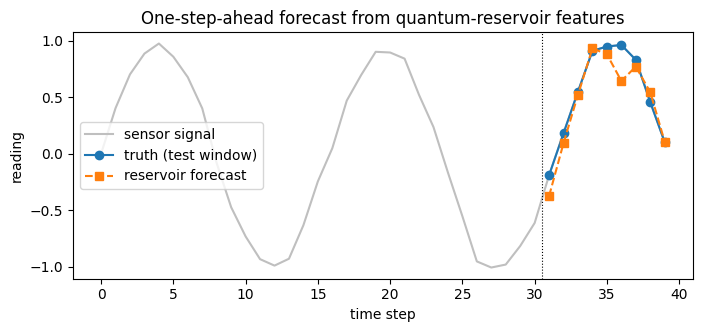

In [10]:
n_train = 30
lam = 1e-2                                        # ridge penalty

Fb = np.hstack([F, np.ones((len(F), 1))])         # add a bias column
A = Fb[:n_train]
w = np.linalg.solve(A.T @ A + lam * np.eye(A.shape[1]), A.T @ y[:n_train])   # the ONLY training
pred = Fb[n_train:] @ w                           # predictions on the held-out window

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

naive = u[n_train:-1]                             # "tomorrow equals today"
print("reservoir RMSE:", round(rmse(pred, y[n_train:]), 3))
print("naive     RMSE:", round(rmse(naive, y[n_train:]), 3))

steps = np.arange(N)
test_steps = steps[n_train + 1:]                  # times of the held-out targets
plt.figure(figsize=(8, 3.2))
plt.plot(steps, u, color="0.75", label="sensor signal")
plt.plot(test_steps, y[n_train:], "o-", label="truth (test window)")
plt.plot(test_steps, pred, "s--", label="reservoir forecast")
plt.axvline(n_train + 0.5, color="k", lw=0.8, ls=":")
plt.xlabel("time step")
plt.ylabel("reading")
plt.title("One-step-ahead forecast from quantum-reservoir features")
plt.legend()
plt.show()

**Reservoir RMSE 0.134 versus naive 0.311**: the trained linear readout on quantum features misses by less than half as much as the baseline, and the plot shows it tracking the turning points that the naive forecaster always lags behind. Note what was actually trained: **one `np.linalg.solve`**. The quantum side never saw a gradient.

The same caveat applies here as throughout the tutorial: at 3 qubits a classical autoregressive model would match this result. What the demo shows is the **workflow** (fixed quantum dynamics as a feature map, followed by a cheap classical head) and the **no-training property** that makes it realistic for near-term analog hardware, where running fixed dynamics is exactly what the machine does well and per-parameter gradient updates are exactly what it does poorly.

### 🧩 Exercise 6.2 · Forecast two steps ahead

One-step forecasting flatters the naive baseline: "tomorrow looks like today" is nearly free. The real test of the reservoir's *memory* is predicting further out, where staleness hurts. Your job: retarget the pipeline to predict **two steps ahead**, $u_{t+2}$ from the features after seeing $u_0 \dots u_t$.

**Goal:** rebuild the dataset for the two-step target, refit the ridge readout, and compare RMSEs against the naive baseline (which must also shift: its freshest available guess for $u_{t+2}$ is still $u_t$, now two steps stale).

**No reservoir re-runs needed:** `F`, `u`, `n_train`, `lam`, and `rmse` are all still in memory; this is a pure re-slicing and refit.

**Hints**

- Row $t$ of `F` holds the features after seeing `u[0..t]`. For a two-step target, pair it with `u[t+2]`: slice the targets as `u[2:]` and drop the last row of `F` (it has nothing left to predict).
- The refit is the demo's four ridge lines with the new `F2`, `y2`.
- Expected outcome: the reservoir degrades gracefully while the naive baseline collapses. That gap *is* the memory of qubits 1 and 2, made visible.

In [11]:
# Everything needed is in memory: u (40 readings), F (39 x 12 features),
# n_train, lam, and the rmse() helper.

# solution: re-slice for the two-step target
y2 = u[2:]                        # y2[t] = u[t+2]: 38 targets
F2 = F[:-1]                       # 38 rows: the last feature row has no u[t+2] to predict

# solution: refit the ridge readout on the two-step dataset
F2b = np.hstack([F2, np.ones((len(F2), 1))])
A2 = F2b[:n_train]
w2 = np.linalg.solve(A2.T @ A2 + lam * np.eye(A2.shape[1]), A2.T @ y2[:n_train])
pred2 = F2b[n_train:] @ w2

naive2 = u[n_train:len(y2)]       # predict u[t+2] := u[t], two steps stale
print("2-step reservoir RMSE:", round(rmse(pred2, y2[n_train:]), 3))
print("2-step naive     RMSE:", round(rmse(naive2, y2[n_train:]), 3))
print("(1-step scores were  : reservoir 0.134, naive 0.311)")

2-step reservoir RMSE: 0.266
2-step naive     RMSE: 0.579
(1-step scores were  : reservoir 0.134, naive 0.311)


## Recap · the big picture

- **One program, any backend, one line.** The H$_2$ energy measurement (a Functional plus a Readout) ran unchanged on `QiliSim` and, wherever the optional extras are installed, on `QutipBackend` and `CudaBackend`, printing the same -1.851199 Ha everywhere. Simulation strategy lives in separate config objects (and pydantic configs silently drop unknown keywords, so check your kwarg names).
- **No lock-in.** The QAOA placement circuit exported to **OpenQASM 3** and **QIR** and round-tripped losslessly: your circuits are portable text, like JSON.
- **The compiler is where hardware gets real.** `CircuitTranspiler` lowered 34 logical gates to a native `RX`/`RY`/`RZ`/`CZ` circuit roughly twice the size and routed every two-qubit gate onto a physical coupler (SABRE). Topology sets the SWAP overhead, and Part 5's per-gate error compounding turns that overhead into answer fidelity. You priced a coupler upgrade with a compiler experiment.
- **On pulse-level control.** The analog `Schedule` is continuous *Hamiltonian-level* control; true pulse-level work (Rabi, $T_1$ calibration) is hardware-side, reached through the `SpeQtrum` job queue with the same functional and readout objects you used all day.
- **Capstone.** A frozen 3-qubit reservoir turned a sensor history into features, and one `np.linalg.solve` trained a forecaster that beat the naive baseline 0.134 to 0.311 RMSE (and degraded far more gracefully two steps out). No quantum training, no gradients, which is exactly the point for near-term analog hardware.

### The journey

**Foundations** (qubits, states, measurement) → **Circuits** (gates, sampling, interference) → **Analog** (Hamiltonians, annealing) → **Variational & Optimization** (VQE, `Model` → QUBO → Hamiltonian, QAOA) → **Noise** (density matrices, channels, error budgets) → **Execution & Hardware** (backends, interop, transpilation, QRC). One small set of primitives (`QTensor`, `Circuit`, `Hamiltonian`, `Schedule`, `Readout`), composed through `Functional`s, executed by a swappable `Backend`. That architecture is the thing to take home: it is how the code you wrote today grows from a laptop demo into a hardware experiment.

### Where to go next

- **Docs** (EN/ES/CA): <https://qilimanjaro-tech.github.io/qilisdk/>
- **Source:** <https://github.com/qilimanjaro-tech/qilisdk>
- **Diagnostics:** `print(qilisdk.about())` shows versions, extras, and available backends on any machine.

**Thank you for spending the day with quantum computing!**